# 📊 Data Science with Python Internship

# Task 4: Mini Visualization Dashboard on Titanic Dataset

---

## Submitted By

**Name:** Rahul Chopra

**Internship:** Data Science with Python Internship

**Organization:** Maincrafts Technology

---

## Project Overview

This project is a part of the Data Science with Python Internship. The objective of this task is to build a Mini Data Visualization Dashboard using the Titanic dataset.

The notebook includes data cleaning, feature engineering, statistical analysis, and multiple visualizations that help understand the survival patterns of Titanic passengers.

The dashboard presents important insights through different types of charts along with brief interpretations, making the analysis more meaningful and easier to understand.

# 🎯 Objective

The main objectives of this project are:

- Load and explore the Titanic dataset.
- Clean the dataset by handling missing values.
- Perform simple feature engineering.
- Create multiple visualizations using Matplotlib and Seaborn.
- Interpret the results obtained from each visualization.
- Build a simple dashboard that communicates important insights from the dataset.

Exploratory Data Analysis (EDA) is one of the most important steps in Data Science because it helps understand the data before applying machine learning models.

# Step 1: Import Required Libraries

Before starting the analysis, we need to import the required Python libraries.

### Libraries Used

- **Pandas** – Used for data loading and manipulation.
- **NumPy** – Used for numerical operations.
- **Matplotlib** – Used for creating charts.
- **Seaborn** – Used for creating attractive statistical visualizations.

These libraries form the foundation of data analysis and visualization in Python.

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Apply Seaborn Style
sns.set(style="whitegrid")

# Ignore Warning Messages
import warnings
warnings.filterwarnings("ignore")

# Step 2: Load the Dataset

The Titanic dataset is loaded into a Pandas DataFrame.

After loading the dataset, the first five records are displayed to ensure that the data has been imported successfully.

This step helps us understand the structure of the dataset before beginning the analysis.

In [3]:
# Load Titanic Dataset

df = pd.read_csv("Titanic-Dataset.csv")

# Display the First Five Rows
df.head()

# Display the Last Five Rows

df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


# Step 3: Dataset Overview

Before performing any analysis, it is important to understand the dataset.

In this section, we examine:

- Dataset Shape
- Column Names
- Data Types
- Missing Values
- Basic Statistical Information

This provides a complete overview of the available information.

In [5]:
# Shape of Dataset

print("Dataset Shape:")
print(df.shape)

# Column Names

print("Columns in Dataset:\n")

for column in df.columns:
    print(column)

# Dataset Information

print("Dataset Information:\n")

df.info()

# Statistical Summary

df.describe()

# Check Missing Values

print("Missing Values in Each Column:\n")

df.isnull().sum()



Dataset Shape:
(891, 12)
Columns in Dataset:

PassengerId
Survived
Pclass
Name
Sex
Age
SibSp
Parch
Ticket
Fare
Cabin
Embarked
Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
Missing Values in Each Column:



PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Step 4: Data Cleaning

Real-world datasets usually contain missing or unnecessary values.

To improve the quality of analysis, the following preprocessing steps are performed:

- Fill missing values in the Age column using the median.
- Fill missing values in the Embarked column using the mode.
- Remove the Cabin column because it contains many missing values.

After cleaning, the dataset becomes more suitable for visualization and analysis.

In [6]:
# Fill Missing Age Values Using Median

df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Missing Embarked Values Using Mode

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Remove Cabin Column

df = df.drop(columns=["Cabin"], errors="ignore")

# Verify Missing Values After Cleaning

print("Missing Values After Cleaning:\n")

df.isnull().sum()

# Check Duplicate Records

print("Number of Duplicate Rows:")

print(df.duplicated().sum())

# Remove Duplicate Rows (if any)

df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:")

print(df.shape)

Missing Values After Cleaning:

Number of Duplicate Rows:
0
Dataset Shape After Removing Duplicates:
(891, 11)


# Step 5: Feature Engineering

Feature engineering is the process of creating new variables that provide more meaningful information.

Two new features are created:

### Family Size

Family Size = SibSp + Parch

This feature represents the total number of family members travelling together.

### Age Group

Passengers are categorized into:

- Child
- Teen
- Young Adult
- Adult
- Senior

Grouping passengers by age helps compare survival rates across different age categories.

In [7]:
# Create Family Size Feature

df["FamilySize"] = df["SibSp"] + df["Parch"]

# Display First Five Records

df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0


In [8]:
# Create Age Groups

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 30, 50, 80],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

# Display Age Groups

df[["Age", "AgeGroup"]].head()

,Age,AgeGroup
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Adult
4,35.0,Adult


In [9]:
# Count Passengers in Each Age Group

df["AgeGroup"].value_counts().sort_index()

AgeGroup
Child           69
Teen            70
Young Adult    447
Adult          241
Senior          64
Name: count, dtype: int64

In [10]:
# Display Updated Dataset

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,Adult


# Dashboard Visualization 1

## Age Distribution (Histogram)

The histogram displays the distribution of passenger ages.

It helps identify:

- Most common age group
- Spread of ages
- Frequency of passengers within different age ranges

This visualization provides an overall understanding of passenger demographics.

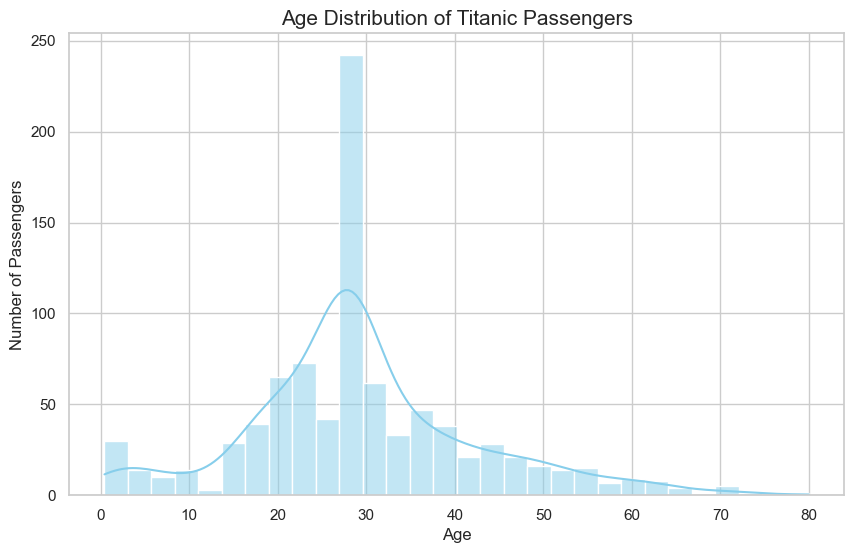

In [11]:
# Age Distribution Histogram

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Age",
    bins=30,
    kde=True,
    color="skyblue"
)

plt.title("Age Distribution of Titanic Passengers", fontsize=15)
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

## 📌 Interpretation

From the histogram, it can be observed that:

- Most passengers were between 20 and 40 years old.
- There were relatively fewer children and senior citizens.
- The age distribution is slightly right-skewed.

This indicates that the majority of passengers were young adults.

# Dashboard Visualization 2

## Survival Rate by Gender

This bar chart compares the average survival rate of male and female passengers.

The objective of this visualization is to determine whether gender had an influence on survival during the Titanic disaster.

In [13]:
# Average Survival Rate by Gender

gender_survival = df.groupby("Sex")["Survived"].mean()

print(gender_survival)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


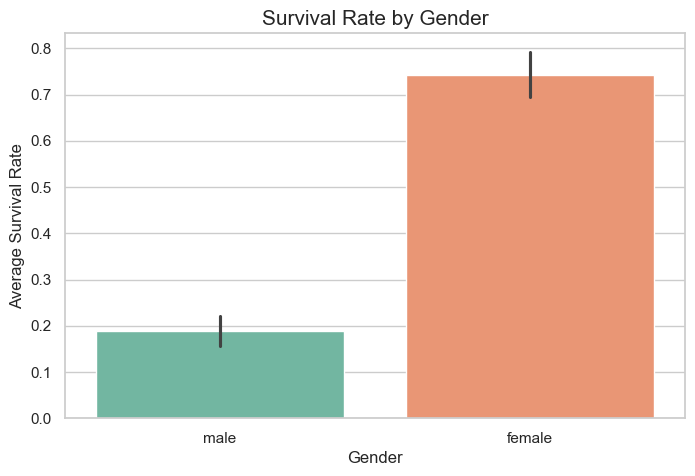

In [12]:
# Survival Rate by Gender

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Sex",
    y="Survived",
    palette="Set2"
)

plt.title("Survival Rate by Gender", fontsize=15)
plt.xlabel("Gender")
plt.ylabel("Average Survival Rate")

plt.show()

## 📌 Interpretation

The chart clearly shows that:

- Female passengers had a significantly higher survival rate.
- Male passengers experienced a lower survival rate.

This suggests that gender played an important role during the rescue process.

# Dashboard Visualization 3

## Fare Distribution by Passenger Class

A box plot is used to visualize the fare distribution across different passenger classes.

The box plot helps identify:

- Median fare
- Spread of fares
- Outliers
- Differences between passenger classes

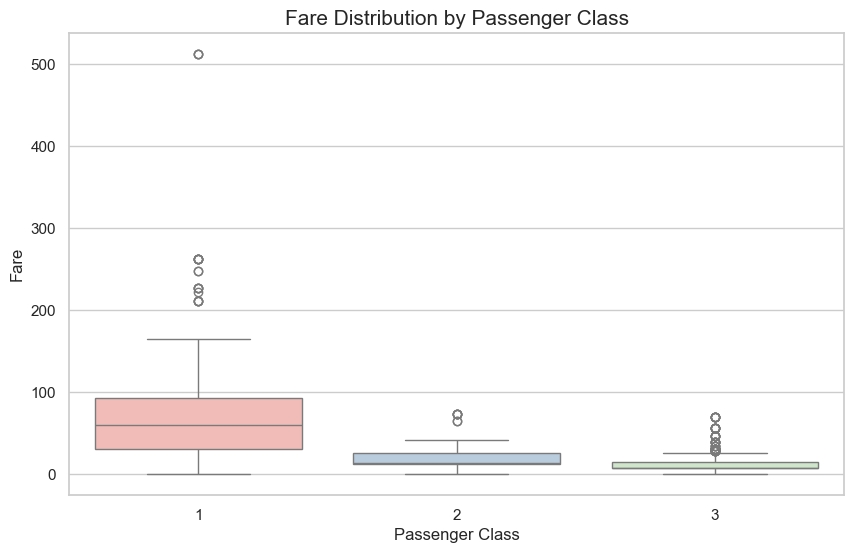

In [14]:
# Fare Distribution by Passenger Class

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Pclass",
    y="Fare",
    palette="Pastel1"
)

plt.title("Fare Distribution by Passenger Class", fontsize=15)
plt.xlabel("Passenger Class")
plt.ylabel("Fare")

plt.show()

## 📌 Interpretation

The box plot indicates that:

- First-class passengers generally paid much higher fares.
- Third-class passengers paid comparatively lower fares.
- Several high-fare outliers are present in the first-class category.

Passenger class had a noticeable impact on ticket prices.

# Dashboard Visualization 4

## Age vs Fare (Scatter Plot)

The scatter plot illustrates the relationship between passenger age and fare.

Passengers are colored according to their survival status, making it easier to identify possible survival patterns.

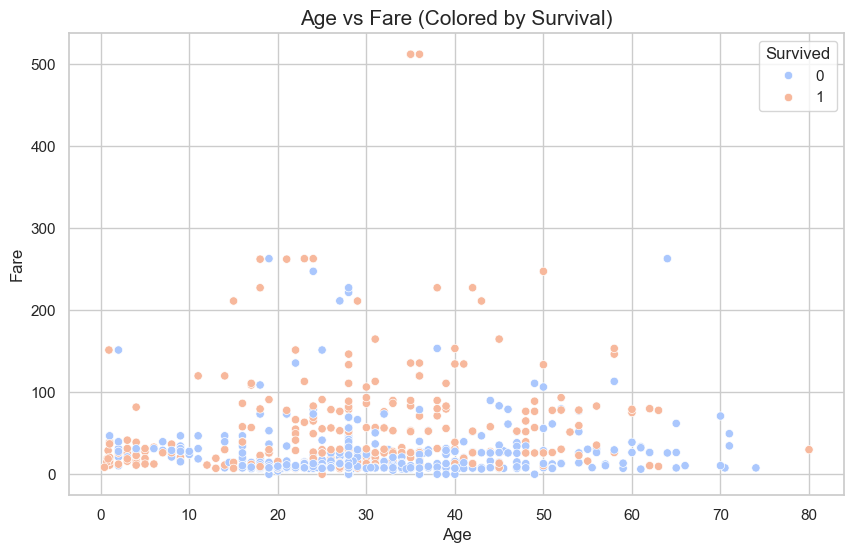

In [15]:
# Scatter Plot

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Survived",
    palette="coolwarm"
)

plt.title("Age vs Fare (Colored by Survival)", fontsize=15)
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

## 📌 Interpretation

From the scatter plot:

- There is no strong linear relationship between Age and Fare.
- Higher fares are mostly associated with first-class passengers.
- Surviving passengers appear more frequently among higher fare values.

This suggests that ticket fare may have influenced survival chances.

# Dashboard Visualization 5

## Correlation Heatmap

The heatmap shows the correlation between all numerical variables.

Correlation values range from:

- +1 → Strong Positive Relationship
- 0 → No Relationship
- -1 → Strong Negative Relationship

This visualization helps identify variables that are strongly related to each other.

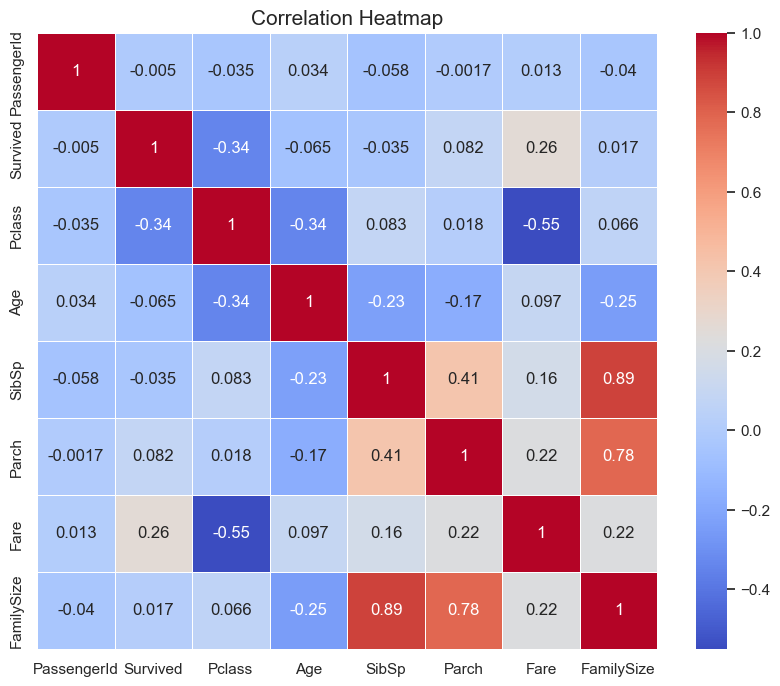

In [16]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=15)

plt.show()

## 📌 Interpretation

The correlation heatmap reveals that:

- Fare has a positive relationship with Survival.
- Passenger Class has a negative relationship with Survival.
- Family-related features have only weak correlations.
- Age has a relatively small effect on Survival.

Overall, Passenger Class and Fare are among the most influential numerical features.

# Dashboard Summary

The dashboard successfully presents important information about the Titanic dataset using multiple visualization techniques.

The combination of histograms, bar charts, box plots, scatter plots, and heatmaps provides a comprehensive understanding of passenger characteristics and survival patterns.

Each visualization highlights a different aspect of the dataset, making the analysis easier to interpret.

In [17]:
# Dashboard Summary Statistics

print("===== Dashboard Summary =====\n")

print(f"Total Passengers : {len(df)}")
print(f"Total Features   : {len(df.columns)}")
print(f"Average Age      : {round(df['Age'].mean(),2)} Years")
print(f"Average Fare     : {round(df['Fare'].mean(),2)}")

print("\nPassenger Class Distribution:")

print(df["Pclass"].value_counts())

print("\nGender Distribution:")

print(df["Sex"].value_counts())

print("\nEmbarkation Port Distribution:")

print(df["Embarked"].value_counts())

===== Dashboard Summary =====

Total Passengers : 891
Total Features   : 13
Average Age      : 29.36 Years
Average Fare     : 32.2

Passenger Class Distribution:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Gender Distribution:
Sex
male      577
female    314
Name: count, dtype: int64

Embarkation Port Distribution:
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


In [18]:
# Survival Statistics

print("===== Survival Statistics =====\n")

survival = df["Survived"].value_counts()

print(survival)

print("\nOverall Survival Rate:")

print(round(df["Survived"].mean()*100,2),"%")

===== Survival Statistics =====

Survived
0    549
1    342
Name: count, dtype: int64

Overall Survival Rate:
38.38 %


In [19]:
# Family Size Statistics

print("Family Size Statistics")

df["FamilySize"].describe()

Family Size Statistics


count    891.000000
mean       0.904602
std        1.613459
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max       10.000000
Name: FamilySize, dtype: float64

In [20]:
# Age Group Distribution

print("Passengers in Each Age Group")

df["AgeGroup"].value_counts().sort_index()

Passengers in Each Age Group


AgeGroup
Child           69
Teen            70
Young Adult    447
Adult          241
Senior          64
Name: count, dtype: int64

# Final Conclusion

In this project, a Mini Visualization Dashboard was successfully created using the Titanic dataset.

The dataset was cleaned by handling missing values and removing unnecessary columns. New features such as Family Size and Age Group were created to improve the analysis.

Multiple visualizations were developed using Matplotlib and Seaborn to explore relationships between different variables. Each chart provided meaningful insights regarding passenger demographics, ticket fares, passenger class, gender, and survival patterns.

This project enhanced my understanding of data cleaning, feature engineering, exploratory data analysis (EDA), and data visualization. These skills are fundamental for solving real-world data science problems and communicating insights effectively.

In [21]:
# Display Final Dataset

df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,Adult
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q,0,Young Adult
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,0,Senior
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S,4,Child
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,2,Young Adult
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,1,Teen


In [22]:
# Display Random Sample

df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,AgeGroup
51,52,0,3,"Nosworthy, Mr. Richard Cater",male,21.0,0,0,A/4. 39886,7.8000,S,0,Young Adult
858,859,1,3,"Baclini, Mrs. Solomon (Latifa Qurban)",female,24.0,0,3,2666,19.2583,C,3,Young Adult
530,531,1,2,"Quick, Miss. Phyllis May",female,2.0,1,1,26360,26.0000,S,2,Child
82,83,1,3,"McDermott, Miss. Brigdet Delia",female,28.0,0,0,330932,7.7875,Q,0,Young Adult
787,788,0,3,"Rice, Master. George Hugh",male,8.0,4,1,382652,29.1250,Q,5,Child
626,627,0,2,"Kirkland, Rev. Charles Leonard",male,57.0,0,0,219533,12.3500,Q,0,Senior
181,182,0,2,"Pernot, Mr. Rene",male,28.0,0,0,SC/PARIS 2131,15.0500,C,0,Young Adult
359,360,1,3,"Mockler, Miss. Helen Mary ""Ellie""",female,28.0,0,0,330980,7.8792,Q,0,Young Adult
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,S,5,Senior
841,842,0,2,"Mudd, Mr. Thomas Charles",male,16.0,0,0,S.O./P.P. 3,10.5000,S,0,Teen


In [23]:
# Final Shape of Dataset

print("Final Dataset Shape")

print(df.shape)

Final Dataset Shape
(891, 13)


In [24]:
# Display Final Column Names

print("Final Dataset Columns")

print(df.columns)

Final Dataset Columns
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize', 'AgeGroup'],
      dtype='object')


In [25]:
# Save Cleaned Dataset

df.to_csv("Titanic_Cleaned_Dataset.csv", index=False)

print("Cleaned Dataset Saved Successfully!")

Cleaned Dataset Saved Successfully!
